# 01 - Dataset EDA

Exploratory look at the synthetic AeroMind dataset: class balance, per-subject epoch counts, and raw signal amplitude distribution. Swap `generate_dataset` for a loader over `data/processed/<real_dataset>` once real STEW data has been preprocessed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.synthetic import CHANNEL_NAMES, WORKLOAD_LABELS, FATIGUE_LABELS, generate_dataset

epochs = generate_dataset(n_subjects=8, duration_s=300.0, seed=42)
print(f'{len(epochs)} epochs across {len({e.subject_id for e in epochs})} subjects')

2392 epochs across 8 subjects


In [2]:
df = pd.DataFrame({
    'subject_id': [e.subject_id for e in epochs],
    'workload': [WORKLOAD_LABELS[e.workload] for e in epochs],
    'fatigue': [FATIGUE_LABELS[e.fatigue] for e in epochs],
})
df.head()

,subject_id,workload,fatigue
0,0,low,alert
1,0,low,alert
2,0,low,alert
3,0,low,alert
4,0,low,alert


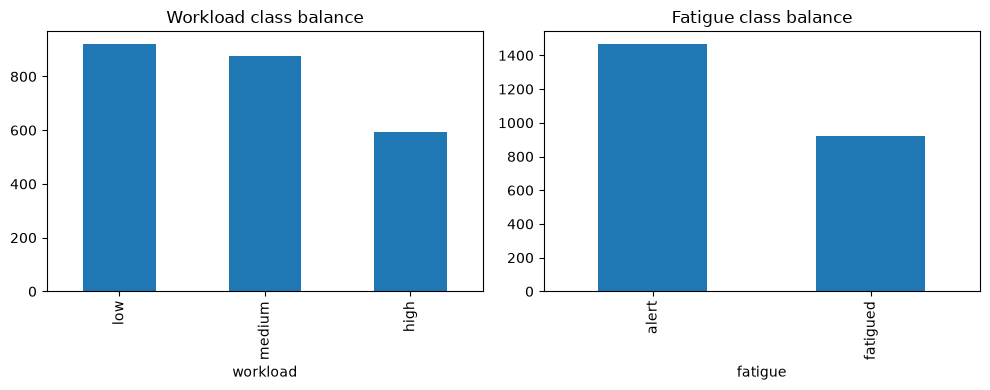

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['workload'].value_counts().reindex(WORKLOAD_LABELS).plot.bar(ax=axes[0], title='Workload class balance')
df['fatigue'].value_counts().reindex(FATIGUE_LABELS).plot.bar(ax=axes[1], title='Fatigue class balance')
plt.tight_layout()
plt.show()

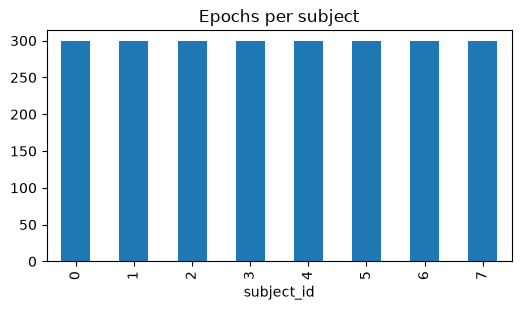

In [4]:
epochs_per_subject = df.groupby('subject_id').size()
epochs_per_subject.plot.bar(title='Epochs per subject', figsize=(6, 3))
plt.show()

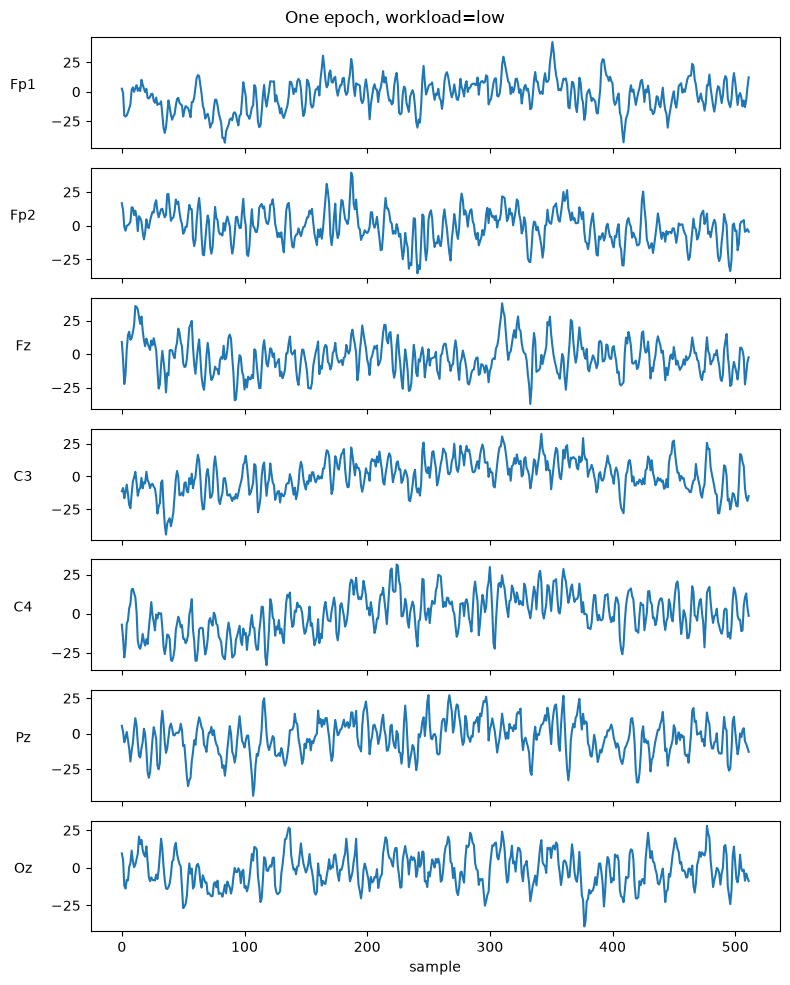

In [5]:
sample = epochs[0].data  # (n_channels, n_samples)
fig, axes = plt.subplots(len(CHANNEL_NAMES), 1, figsize=(8, 10), sharex=True)
for ax, ch_name, row in zip(axes, CHANNEL_NAMES, sample):
    ax.plot(row)
    ax.set_ylabel(ch_name, rotation=0, labelpad=20)
axes[-1].set_xlabel('sample')
fig.suptitle(f'One epoch, workload={WORKLOAD_LABELS[epochs[0].workload]}')
plt.tight_layout()
plt.show()